# 03 Preprocessing — WLC-Eignungsfaktoren

**PA1 ZHAW IUNR** | Bächler, Haag, Reichlin | Betreuer: Patrick Laube

Prüft und verarbeitet alle Datensätze für die Weighted Linear Combination.

**Input:**
```
data/processed/constraints/constraint_mask_s2.tif
data/processed/dem/dem_gr_25m.tif, slope_gr_25m.tif, aspect_gr_25m.tif
data/raw/solar/                    BFE Solareinstrahlung (30°, 75°)
data/raw/snow/                     SPASS Schneebedeckung
data/raw/tlm3d/                    swissTLM3D (Strassen, Leitungen, Staumauern, Gebäude)
```

**Output:**
```
data/processed/criteria/f01–f10_*.tif     (10 normalisierte Eignungsfaktoren [0, 1])
data/processed/distances/dist_*.tif       (Distanz-Raster)
```

Dieses Notebook ist unabhängig von 01/02a ausführbar — eine beliebige binäre Maske reicht als Input.

## 1. Setup

In [1]:
from pathlib import Path
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_bounds
from rasterio.features import rasterize
from rasterio.warp import reproject
from scipy.ndimage import distance_transform_edt
import fiona
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")                                          # Warnungen unterdrücken

# --- Pfade ---
RAW  = Path("../data/raw")                                                # Rohdaten
PROC = Path("../data/processed")                                           # Prozessierte Daten
OUT  = Path("../outputs/figures")                                          # Figuren-Output
for d in [PROC / "criteria", PROC / "distances", OUT]:
    d.mkdir(parents=True, exist_ok=True)

# --- Konstanten ---
CRS    = "EPSG:2056"                                                       # Ziel-CRS (LV95)
RES    = 25                                                                # Pixelauflösung [m]
NODATA = -9999.0                                                           # NoData-Wert

print("✓ Setup OK")

✓ Setup OK


## 2. Constraint-Maske & Referenzraster laden

In [2]:
print("=== Constraint-Maske & Referenzraster laden ===\n")

# --- Constraint-Maske (aus 02a) ---
mask_path = PROC / "constraints/constraint_mask_s2.tif"
with rasterio.open(mask_path) as src:
    constraint_mask = src.read(1)                                          # binäre Maske (0/1)
    transform = src.transform                                              # Affine-Transformation
    ref_profile = src.profile.copy()                                       # Referenzprofil für Outputs
    ref_profile.update(dtype="float32", nodata=NODATA)
    height, width = constraint_mask.shape                                  # Rasterdimensionen

# --- DEM-Ableitungen (aus 02a) ---
with rasterio.open(PROC / "dem/dem_gr_25m.tif") as src:
    dem = src.read(1)                                                      # Höhe [m]
with rasterio.open(PROC / "dem/slope_gr_25m.tif") as src:
    slope = src.read(1)                                                    # Hangneigung [°]
with rasterio.open(PROC / "dem/aspect_gr_25m.tif") as src:
    aspect = src.read(1)                                                   # Exposition [0–360°]

# --- Gültigkeitsmaske ---
valid = (dem != NODATA) & (constraint_mask == 1)                           # geeignet + DEM vorhanden
print(f"  Constraint-Maske: {constraint_mask.sum():,} Pixel ({constraint_mask.sum()*RES*RES/1e6:.0f} km²)")
print(f"  Raster: {width}×{height} @ {RES}m")

=== Constraint-Maske & Referenzraster laden ===

  Constraint-Maske: 626,229 Pixel (391 km²)
  Raster: 5641×4010 @ 25m


In [3]:
def normalize_linear(data, low, high, invert=False):
    """Lineare Min-Max-Normalisierung auf [0, 1]."""
    out = np.full_like(data, NODATA)
    m = valid & (data != NODATA)                                           # gültige Pixel
    vals = np.clip((data[m] - low) / (high - low), 0, 1)                  # normalisieren + clippen
    out[m] = 1 - vals if invert else vals                                  # optional invertieren
    return out


def normalize_piecewise(data, breakpoints, values):
    """Stückweise lineare Normalisierung via Interpolation."""
    out = np.full_like(data, NODATA)
    m = valid & (data != NODATA)                                           # gültige Pixel
    out[m] = np.interp(data[m], breakpoints, values)                       # Stützstellen interpolieren
    return out


def save_criterion(data, name):
    """Speichert ein normalisiertes Kriterium als GeoTIFF."""
    path = PROC / f"criteria/{name}.tif"
    with rasterio.open(path, "w", **ref_profile) as dst:
        dst.write(data, 1)                                                 # Band 1 schreiben
    v = data[valid & (data != NODATA)]                                     # Statistik
    print(f"  {name}: {v.min():.3f}–{v.max():.3f} (mean {v.mean():.3f})")


def rasterize_to_grid(gdf, burn=1):
    """Rasterisiert Vektordaten auf das Referenzgitter."""
    shapes = [(g, burn) for g in gdf.to_crs(CRS).geometry if g is not None]
    if not shapes:
        return np.zeros((height, width), dtype=np.uint8)
    return rasterize(shapes, out_shape=(height, width), transform=transform, fill=0, dtype=np.uint8)


def compute_distance(binary_raster, name):
    """Berechnet euklidische Distanz zu Binärraster-Features."""
    dist = distance_transform_edt(                                         # Distanztransformation
        (binary_raster == 0).astype(float), sampling=(RES, RES)
    ).astype(np.float32)
    with rasterio.open(PROC / f"distances/{name}.tif", "w", **ref_profile) as dst:
        dst.write(dist, 1)                                                 # Distanzraster speichern
    print(f"  {name}: max {dist[valid].max():.0f} m")
    return dist


print("✓ Funktionen definiert")

✓ Funktionen definiert


## 3. Datenprüfung — WLC-Datensätze

Qualitätskontrolle der Datensätze die NUR für WLC relevant sind (nicht für Constraints).

In [4]:
print("=== WLC-Datensätze prüfen ===\n")

# --- BFE Solar (4 Neigungswinkel) ---
for deg in ["0", "30", "75", "90"]:
    parent = RAW / "solar" / f"solarenergie-einstrahlung_{deg}_grad_2056.gpkg"
    gpkg = next(parent.glob("*.gpkg"), None) if parent.is_dir() else (parent if parent.exists() else None)
    if gpkg:
        gdf = gpd.read_file(gpkg, rows=slice(0, 1))                       # nur 1 Zeile für CRS-Check
        print(f"  BFE Solar {deg}°: ✓ CRS={gdf.crs}")
    else:
        print(f"  BFE Solar {deg}°: ⚠ FEHLT")

# --- SPASS Schnee ---
spass = sorted((RAW / "snow").glob("**/*.nc"))
print(f"  SPASS Schnee: {'✓ ' + spass[0].name if spass else '⚠ FEHLT'}")

# --- swissTLM3D ---
tlm_path = RAW / "tlm3d/swisstlm3d_2026-02-24_2056_5728.gpkg"
if tlm_path.is_dir():                                                     # .gpkg kann Verzeichnis sein
    tlm_path = next(tlm_path.glob("*.gpkg"))
print(f"  swissTLM3D: {'✓' if tlm_path.exists() else '⚠ FEHLT'}")

=== WLC-Datensätze prüfen ===

  BFE Solar 0°: ✓ CRS=EPSG:2056
  BFE Solar 30°: ✓ CRS=EPSG:2056
  BFE Solar 75°: ✓ CRS=EPSG:2056
  BFE Solar 90°: ✓ CRS=EPSG:2056
  SPASS Schnee: ✓ SWECLQMD_ch01h.swiss.lv95_WY_1962_2023.nc
  swissTLM3D: ✓


## 4. BFE Solar → Raster

In [5]:
print("=== BFE Solar → Raster ===\n")

# --- Bounding Box des Referenzrasters ---
bbox = (transform.c, transform.f + height * transform.e,
        transform.c + width * transform.a, transform.f)

# ╔══════════════════════════════════════════════════════════╗
# ║  BFE Solar: 2 Neigungen einlesen, auf 45° interpolieren ║
# ╚══════════════════════════════════════════════════════════╝

TILT_ANGLES = [30, 75]                                                     # verfügbare Neigungswinkel
COL_JAHR  = "Globalstrahlung_Jahressumme_kWhm2"                           # Jahressumme-Spalte
COL_WINTER = "Globalstrahlung_Wintersumme_kWhm2"                          # Wintersumme-Spalte

solar_jahr = {}                                                            # {tilt_deg: raster}
solar_winter = {}                                                          # {tilt_deg: raster}

# --- Schritt 1: Datensätze einlesen & rasterisieren ---
for deg in TILT_ANGLES:
    parent = RAW / "solar" / f"solarenergie-einstrahlung_{deg}_grad_2056.gpkg"
    gpkg = next(parent.glob("*.gpkg")) if parent.is_dir() else parent      # GPKG-Pfad
    if not gpkg.exists():
        print(f"  ⚠ BFE Solar {deg}°: FEHLT — übersprungen")
        continue
    print(f"  Lese BFE Solar {deg}° …")
    gdf_s = gpd.read_file(gpkg, bbox=bbox)                                # nur GR-Extent
    print(f"    {len(gdf_s)} Features | Jahr: {gdf_s[COL_JAHR].min():.0f}–{gdf_s[COL_JAHR].max():.0f} kWh/m²")

    for col, store in [(COL_JAHR, solar_jahr), (COL_WINTER, solar_winter)]:
        shapes = [(g, v) for g, v in zip(gdf_s.geometry, gdf_s[col]) if g is not None and not np.isnan(v)]
        store[deg] = rasterize(shapes, out_shape=(height, width), transform=transform, fill=NODATA, dtype=np.float32)

    del gdf_s                                                              # Speicher freigeben

print(f"\n  Geladene Neigungen: {sorted(solar_jahr.keys())}")

# --- Schritt 2: Pixelweise Interpolation auf 45° ---
TARGET_TILT = 45                                                           # Ziel-Installationswinkel
available_tilts = sorted(solar_jahr.keys())

def interpolate_tilt(raster_dict, tilts, target):
    """Pixelweise lineare Interpolation über Neigungswinkel."""
    stack = np.stack([raster_dict[t] for t in tilts], axis=0)              # (n_tilts, H, W)
    out = np.full((height, width), NODATA, dtype=np.float32)
    m = np.all(stack != NODATA, axis=0)                                    # nur wo alle Neigungen gültig
    tilts_arr = np.array(tilts, dtype=np.float64)
    idx = np.clip(np.searchsorted(tilts_arr, target, side="right"), 1, len(tilts) - 1)
    t_lo, t_hi = tilts_arr[idx - 1], tilts_arr[idx]                       # untere/obere Stützstelle
    w = (target - t_lo) / (t_hi - t_lo) if t_hi != t_lo else 0.0         # Interpolationsgewicht
    out[m] = (1 - w) * stack[idx - 1][m] + w * stack[idx][m]              # lineare Interpolation
    return out

print(f"  Interpoliere auf {TARGET_TILT}° (aus {available_tilts}) …")
rast_jahr_45  = interpolate_tilt(solar_jahr,  available_tilts, TARGET_TILT)
rast_winter_45 = interpolate_tilt(solar_winter, available_tilts, TARGET_TILT)

# --- Schritt 3: Normalisieren & speichern ---
v_j = rast_jahr_45[valid & (rast_jahr_45 != NODATA)]                      # gültige Jahreswerte
f01 = normalize_linear(rast_jahr_45, v_j.min(), v_j.max())                # F01: höher = besser
save_criterion(f01, "f01_globalstrahlung")
print(f"  → Jahressumme bei {TARGET_TILT}°: {v_j.min():.0f}–{v_j.max():.0f} kWh/m²/a")

v_w = rast_winter_45[valid & (rast_winter_45 != NODATA)]                  # gültige Winterwerte
f02 = normalize_linear(rast_winter_45, v_w.min(), v_w.max())              # F02: höher = besser
save_criterion(f02, "f02_wintereinstrahlung")
print(f"  → Wintersumme bei {TARGET_TILT}°: {v_w.min():.0f}–{v_w.max():.0f} kWh/m²")

=== BFE Solar → Raster ===

  Lese BFE Solar 30° …
    4150565 Features | Jahr: 13–2000 kWh/m²
  Lese BFE Solar 75° …
    4150565 Features | Jahr: 29–1931 kWh/m²

  Geladene Neigungen: [30, 75]
  Interpoliere auf 45° (aus [30, 75]) …
  f01_globalstrahlung: 0.000–1.000 (mean 0.847)
  → Jahressumme bei 45°: 224–1861 kWh/m²/a
  f02_wintereinstrahlung: 0.000–1.000 (mean 0.747)
  → Wintersumme bei 45°: 45–877 kWh/m²


In [6]:
# --- Zusammenfassung BFE Solar ---
print(f"F01: Globalstrahlung Jahressumme bei {TARGET_TILT}° (interpoliert aus {available_tilts})")
print(f"F02: Wintereinstrahlung Okt–Mär bei {TARGET_TILT}° (interpoliert aus {available_tilts})")
print(f"Spalten: {COL_JAHR} / {COL_WINTER}")

F01: Globalstrahlung Jahressumme bei 45° (interpoliert aus [30, 75])
F02: Wintereinstrahlung Okt–Mär bei 45° (interpoliert aus [30, 75])
Spalten: Globalstrahlung_Jahressumme_kWhm2 / Globalstrahlung_Wintersumme_kWhm2


## 5. DEM-basierte Eignungsfaktoren

In [7]:
print("=== F03–F05: DEM-basierte Eignungsfaktoren ===\n")

# --- F03: Hangneigung (Optimum 20–30°) ---
f03 = normalize_piecewise(slope, [0, 20, 30, 45, 90], [0, 1, 1, 0, 0])   # Plateau bei 20–30°
save_criterion(f03, "f03_hangneigung")

# --- F04: Exposition (Südabweichung → höherer Score) ---
south_dev = np.abs(aspect - 180)                                           # Abweichung von Süden [°]
f04 = normalize_linear(south_dev, 180, 0)                                  # 0° Abweichung = 1.0
save_criterion(f04, "f04_exposition")

# --- F05: Höhenlage (Optimum 1800–2500 m) ---
f05 = normalize_piecewise(dem, [1500, 1800, 2500, 2700], [0, 1, 1, 0])    # Plateau bei 1800–2500 m
save_criterion(f05, "f05_hoehenlage")

=== F03–F05: DEM-basierte Eignungsfaktoren ===



  f03_hangneigung: 0.000–1.000 (mean 0.878)
  f04_exposition: 0.667–1.000 (mean 0.831)
  f05_hoehenlage: 0.000–1.000 (mean 0.874)


## 6. SPASS Schneebedeckung

In [8]:
print("=== F06: Schneebedeckung (SPASS) ===\n")

spass_files = sorted((RAW / "snow").glob("**/*.nc"))
if not spass_files:
    print("  ⚠ SPASS nicht gefunden — F06 übersprungen")
else:
    import xarray as xr
    ds = xr.open_dataset(spass_files[0], engine="h5netcdf", decode_times=False)
    swe_var = next((v for v in ds.data_vars if "swe" in v.lower()), list(ds.data_vars)[0])
    print(f"  Datei: {spass_files[0].name} | Var: {swe_var} | Dims: {dict(ds.dims)}")

    # --- Schneebedeckungs-Häufigkeit berechnen ---
    snow_frac = (ds[swe_var] > 0).mean(dim="time").values.astype(np.float32)  # Anteil schneebedeckter Tage

    # --- Koordinaten bestimmen ---
    if "E" in ds.dims:
        x, y = ds["E"].values, ds["N"].values                             # Easting/Northing
    elif "chx" in ds.dims:
        x, y = ds["chx"].values, ds["chy"].values                         # CH-Koordinaten
    else:
        x, y = ds[list(ds.dims)[1]].values, ds[list(ds.dims)[0]].values

    # --- Auf 25 m Referenzgitter reprojizieren ---
    src_tf = from_bounds(x.min(), y.min(), x.max(), y.max(), len(x), len(y))
    snow_25m = np.full((height, width), NODATA, dtype=np.float32)
    reproject(
        source=np.flipud(snow_frac), destination=snow_25m,
        src_transform=src_tf, src_crs=CRS,
        dst_transform=transform, dst_crs=CRS,
        resampling=Resampling.bilinear,
        src_nodata=np.nan, dst_nodata=NODATA
    )

    # --- F06: Mehr Schnee = höherer Albedo-Bonus = besser ---
    v_s = snow_25m[valid & (snow_25m != NODATA)]                           # gültige Werte
    f06 = normalize_linear(snow_25m, v_s.min(), v_s.max())                 # Linear [0, 1]
    save_criterion(f06, "f06_schneebedeckung")
    print(f"  Daten: {v_s.min():.2f}–{v_s.max():.2f} | Mehr Schnee = besser")
    ds.close()

=== F06: Schneebedeckung (SPASS) ===

  Datei: SWECLQMD_ch01h.swiss.lv95_WY_1962_2023.nc | Var: SWECLQMD | Dims: {'time': 22645, 'E': 370, 'N': 265}
  f06_schneebedeckung: 0.000–1.000 (mean 0.743)
  Daten: 0.00–1.00 | Mehr Schnee = besser


## 7. Distanz-Raster (Strasse, Netz, Infrastruktur)

In [9]:
print("=== F07–F09: Distanz-Raster ===\n")

# --- Strassen aus swissTLM3D (ohne Wege/Pfade) ---
EXCLUDE_OBJEKTART = {"1m Weg", "2m Weg", "1m Wegfragment", "2m Wegfragment",
                     "Markierte Spur", "Klettersteig", "Faehre", "Autozug"}
strassen_all = gpd.read_file(str(tlm_path), layer="tlm_strassen_strasse", bbox=bbox)
strassen = strassen_all[~strassen_all["objektart"].isin(EXCLUDE_OBJEKTART)]  # nur befahrbare Strassen
print(f"  Strassen: {len(strassen)} von {len(strassen_all)} (ohne Wege/Pfade)")
del strassen_all                                                           # Speicher freigeben
strassen_raster = rasterize_to_grid(strassen)                              # Binärraster
dist_strasse = compute_distance(strassen_raster, "dist_strasse_gr_25m")

# --- Stromleitungen aus swissTLM3D ---
leitungen = gpd.read_file(str(tlm_path), layer="tlm_bauten_leitung", bbox=bbox)
print(f"  Stromleitungen: {len(leitungen)} Features")
netz_raster = rasterize_to_grid(leitungen)                                 # Binärraster
dist_netz = compute_distance(netz_raster, "dist_netz_gr_25m")

# --- Staumauern aus swissTLM3D ---
try:
    staumauern = gpd.read_file(str(tlm_path), layer="tlm_bauten_staubaute", bbox=bbox)
    print(f"  Staumauern: {len(staumauern)} Features")
    infra_raster = rasterize_to_grid(staumauern)                           # Binärraster
    dist_infra = compute_distance(infra_raster, "dist_infrastruktur_gr_25m")
except Exception:
    print("  ⚠ Staumauer-Layer nicht gefunden")
    dist_infra = np.full((height, width), 10000, dtype=np.float32)         # Fallback

# --- Normalisieren (invers: kürzere Distanz = höherer Score) ---
print()
for name, dist, fid in [("netzanschluss", dist_netz, "f07"),
                         ("strasse", dist_strasse, "f08"),
                         ("infrastruktur", dist_infra, "f09")]:
    v_d = dist[valid & (dist != NODATA)]                                   # gültige Distanzen
    f = normalize_linear(dist, v_d.min(), v_d.max(), invert=True)          # invers normalisieren
    save_criterion(f, f"{fid}_{name}")
    print(f"  {fid}: {v_d.min():.0f}–{v_d.max():.0f} m (invers)")

=== F07–F09: Distanz-Raster ===

  Strassen: 69206 von 187910 (ohne Wege/Pfade)
  dist_strasse_gr_25m: max 8128 m
  Stromleitungen: 299 Features
  dist_netz_gr_25m: max 17262 m
  Staumauern: 3057 Features
  dist_infrastruktur_gr_25m: max 11532 m

  f07_netzanschluss: 0.000–1.000 (mean 0.750)
  f07: 0–17262 m (invers)
  f08_strasse: 0.000–1.000 (mean 0.731)
  f08: 0–8128 m (invers)
  f09_infrastruktur: 0.000–1.000 (mean 0.669)
  f09: 0–11532 m (invers)


## 8. Sichtbarkeit (Proxy)

In [10]:
print("=== F10: Sichtbarkeit (Distanz zu Siedlungen) ===\n")

# --- Gebäude-Footprints als Siedlungs-Proxy ---
gebaeude = gpd.read_file(str(tlm_path), layer="tlm_bauten_gebaeude_footprint", bbox=bbox)
print(f"  Gebäude-Footprints: {len(gebaeude)} Features")

siedl_raster = rasterize_to_grid(gebaeude)                                 # Binärraster
dist_siedlung = distance_transform_edt(                                    # Distanz zu Siedlungen
    (siedl_raster == 0).astype(float), sampling=(RES, RES)
).astype(np.float32)

# --- F10: Weiter = weniger sichtbar = besser ---
v_s = dist_siedlung[valid]                                                 # gültige Distanzen
f10 = normalize_linear(dist_siedlung, v_s.min(), v_s.max())                # Linear [0, 1]
save_criterion(f10, "f10_sichtbarkeit")
print(f"  Daten: {v_s.min():.0f}–{v_s.max():.0f} m | Weiter = weniger sichtbar = besser")

=== F10: Sichtbarkeit (Distanz zu Siedlungen) ===

  Gebäude-Footprints: 343695 Features
  f10_sichtbarkeit: 0.000–1.000 (mean 0.187)
  Daten: 300–6120 m | Weiter = weniger sichtbar = besser


## 9. Übersicht — Normalisierte Eignungsfaktoren

=== Übersicht — Normalisierte Eignungsfaktoren ===



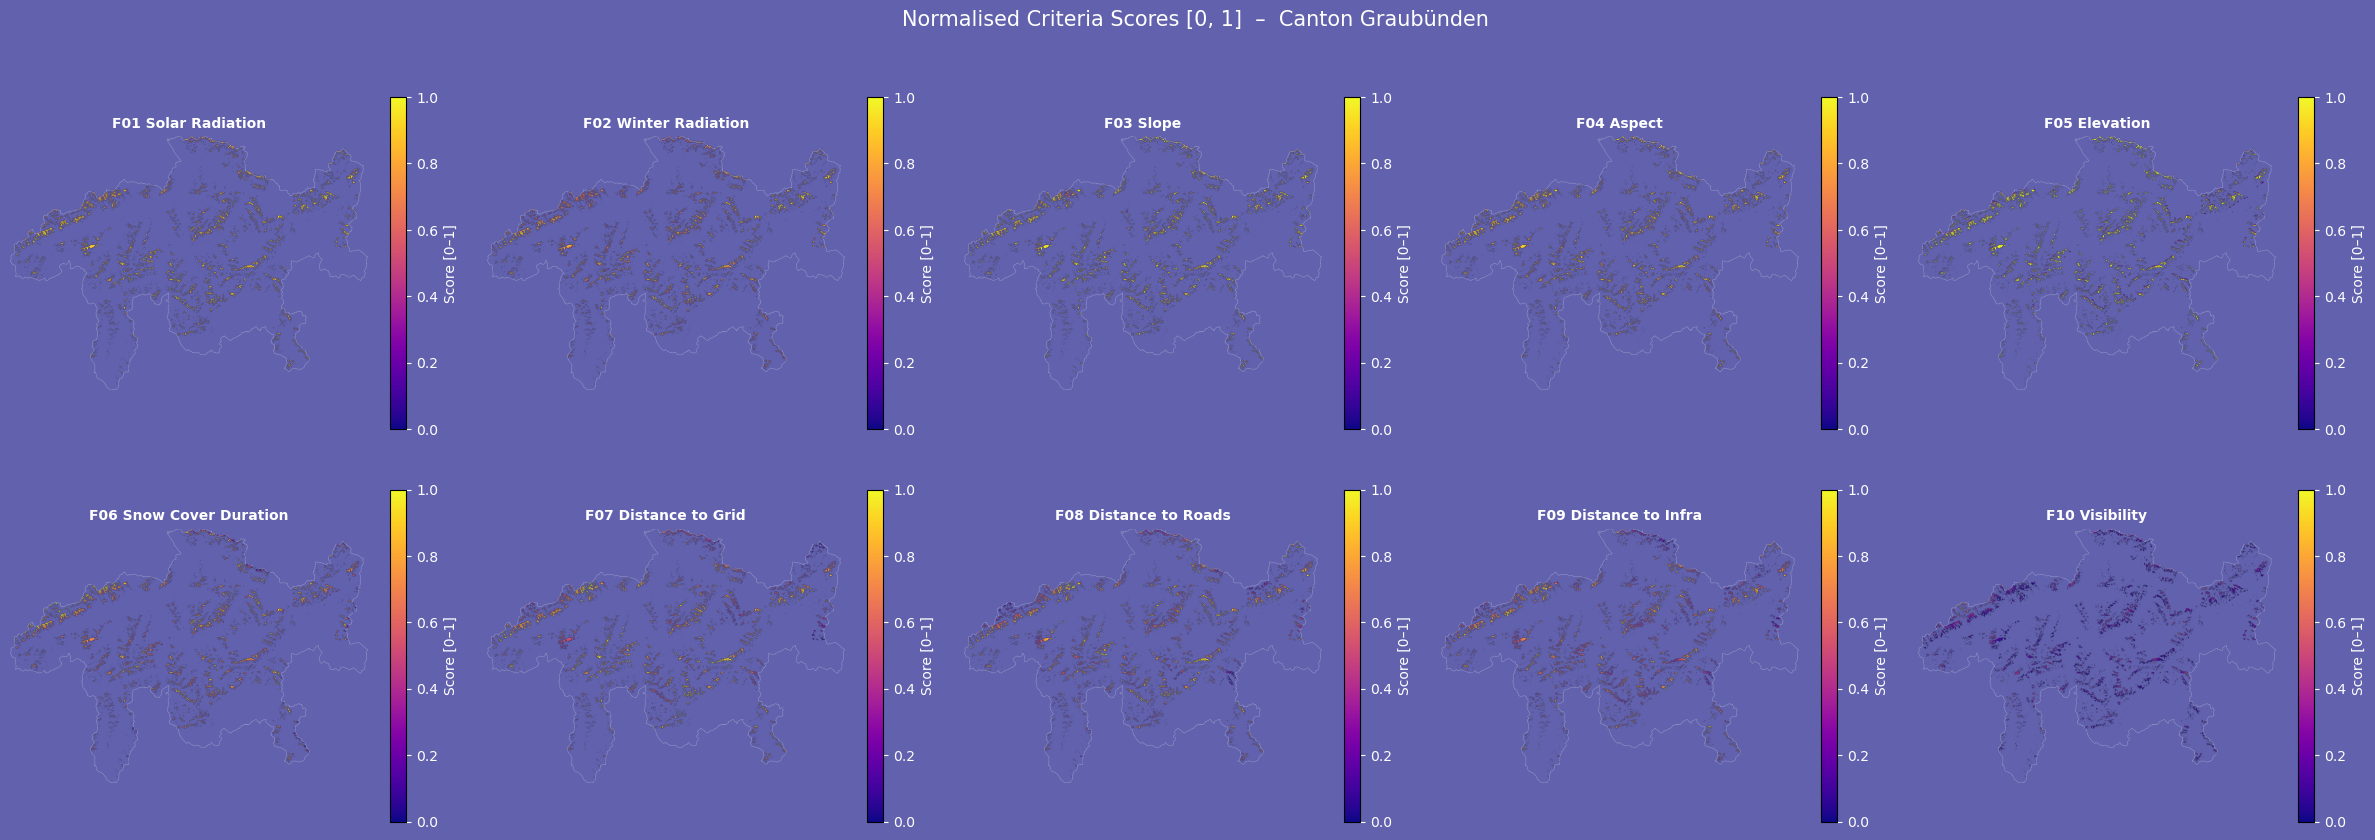

✓ Gespeichert: ..\outputs\figures\criteria_overview.png


In [11]:
print("=== Übersicht — Normalisierte Eignungsfaktoren ===\n")

# --- Alle 10 Kriterien ---
criteria_files = {
    "F01 Solar Radiation":       "f01_globalstrahlung",
    "F02 Winter Radiation":      "f02_wintereinstrahlung",
    "F03 Slope":                 "f03_hangneigung",
    "F04 Aspect":                "f04_exposition",
    "F05 Elevation":             "f05_hoehenlage",
    "F06 Snow Cover Duration":   "f06_schneebedeckung",
    "F07 Distance to Grid":      "f07_netzanschluss",
    "F08 Distance to Roads":     "f08_strasse",
    "F09 Distance to Infra":     "f09_infrastruktur",
    "F10 Visibility":            "f10_sichtbarkeit",
}

# --- Kantonsgrenze für Kontur ---
gr_border = gpd.read_file(RAW / "swissboundaries/graubuenden_kantonsgrenze.shp").to_crs(CRS)
inv_tf = ~transform                                                        # Affine-Inverse: Welt → Pixel

def world_to_pixel(coords):
    """Konvertiert Weltkoordinaten zu Pixelkoordinaten."""
    arr = np.array(list(coords))
    xs, ys = arr[:, 0], arr[:, 1]
    cols, rows = inv_tf * (xs, ys)
    return rows, cols

# --- 2×5 Übersichtskarte ---
BG_COLOR = "#6161AD"
fig, axes = plt.subplots(2, 5, figsize=(24, 9), facecolor=BG_COLOR)
fig.suptitle("Normalised Criteria Scores [0, 1]  –  Canton Graubünden", fontsize=15, y=0.98, color="white")

for ax, (label, fname) in zip(axes.flat, criteria_files.items()):
    ax.set_facecolor(BG_COLOR)
    # Kantonsumriss zeichnen
    for geom in gr_border.geometry:
        polys = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]
        for poly in polys:
            rows, cols = world_to_pixel(poly.exterior.coords)
            ax.plot(cols, rows, color="white", linewidth=0.4, alpha=0.3)

    path = PROC / f"criteria/{fname}.tif"
    if not path.exists():                                                  # Kriterium fehlt
        ax.set_title(f"{label}\n⚠ fehlt", fontsize=10, color="white")
        ax.set_axis_off()
        continue

    with rasterio.open(path) as src:
        data = src.read(1)
    display = np.where(valid & (data != NODATA), data, np.nan)            # nur gültige Pixel anzeigen
    im = ax.imshow(display, cmap="plasma", vmin=0, vmax=1)
    ax.set_title(label, fontsize=10, fontweight="bold", color="white")
    ax.set_axis_off()
    cbar = plt.colorbar(im, ax=ax, label="Score [0–1]", shrink=0.75)      # Farbskala
    cbar.ax.yaxis.set_tick_params(color="white")
    cbar.ax.yaxis.label.set_color("white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

plt.tight_layout()
fig.savefig(OUT / "criteria_overview.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print(f"✓ Gespeichert: {OUT / 'criteria_overview.png'}")

## 10. MCE-Übersicht — WLC-Eignungsfaktoren

In [12]:
print("=== MCE-Übersicht: WLC-Eignungsfaktoren ===\n")

# --- Hilfsfunktionen ---
def _ok(p):                                                                # Existenzprüfung ✓/✗
    return "✓" if (p is not None and Path(p).exists()) else "✗"

def _stats(fname):                                                         # Score-Statistik aus Datei
    path = PROC / f"criteria/{fname}.tif"
    if not path.exists():
        return "—", "—"
    with rasterio.open(path) as src:
        d = src.read(1)
    v = d[(d != NODATA) & valid]
    return f"{v.mean():.3f}", f"{v.std():.3f}" if v.size else ("—", "—")

# --- Dynamische Quellpfade ---
_solar_30 = RAW / "solar/solarenergie-einstrahlung_30_grad_2056.gpkg"
_solar_75 = RAW / "solar/solarenergie-einstrahlung_75_grad_2056.gpkg"
_spass    = sorted((RAW / "snow").glob("**/*.nc"))
_dem_proc = PROC / "dem/dem_gr_25m.tif"
_slope    = PROC / "dem/slope_gr_25m.tif"
_aspect   = PROC / "dem/aspect_gr_25m.tif"

print(f"  BFE Solar 30°:  {_ok(_solar_30)} ({_solar_30.name})")
print(f"  BFE Solar 75°:  {_ok(_solar_75)} ({_solar_75.name})")
print(f"  SPASS Schnee:   {_ok(_spass[0]) if _spass else '✗'} ({_spass[0].name if _spass else '—'})")
print(f"  DEM (proc.):    {_ok(_dem_proc)} ({_dem_proc.name})")
print(f"  Slope (proc.):  {_ok(_slope)} ({_slope.name})")
print(f"  Aspect (proc.): {_ok(_aspect)} ({_aspect.name})")
print(f"  swissTLM3D:     {_ok(tlm_path)} ({tlm_path.name})\n")

# --- Alle 10 Eignungsfaktoren (S2-Szenario) ---
wlc = pd.DataFrame([
    {"ID": "F01", "Kriterium": "Globalstrahlung (Jahressumme)",         "Normalisierung": "Linear [0,1]: (x−min)/(max−min)",                            "Datenquelle": f"BFE Solar ({_solar_30.name} + {_solar_75.name} → 45° interp.)",  "Format": "Vektor → Raster",  "Aufl.": "200 m",  "Mean": _stats("f01_globalstrahlung")[0],    "Std": _stats("f01_globalstrahlung")[1],    "✓": _ok(PROC / "criteria/f01_globalstrahlung.tif")},
    {"ID": "F02", "Kriterium": "Wintereinstrahlung (Okt–Mär)",          "Normalisierung": "Linear [0,1]: (x−min)/(max−min)",                            "Datenquelle": f"BFE Solar ({_solar_30.name} + {_solar_75.name} → 45° interp.)",  "Format": "Vektor → Raster",  "Aufl.": "200 m",  "Mean": _stats("f02_wintereinstrahlung")[0], "Std": _stats("f02_wintereinstrahlung")[1], "✓": _ok(PROC / "criteria/f02_wintereinstrahlung.tif")},
    {"ID": "F03", "Kriterium": "Hangneigung (Optimum 20–30°)",          "Normalisierung": "Stückweise: 0→0, 20→1, 30→1, 45→0, 90→0",                   "Datenquelle": f"DHM25 ({_slope.name})",                                          "Format": "Raster",           "Aufl.": "25 m",   "Mean": _stats("f03_hangneigung")[0],       "Std": _stats("f03_hangneigung")[1],       "✓": _ok(PROC / "criteria/f03_hangneigung.tif")},
    {"ID": "F04", "Kriterium": "Exposition (Südabweichung)",            "Normalisierung": "Linear: S=1.0, N=0.0 (|aspect−180°|)",                       "Datenquelle": f"DHM25 ({_aspect.name})",                                         "Format": "Raster",           "Aufl.": "25 m",   "Mean": _stats("f04_exposition")[0],        "Std": _stats("f04_exposition")[1],        "✓": _ok(PROC / "criteria/f04_exposition.tif")},
    {"ID": "F05", "Kriterium": "Höhenlage (Optimum 1800–2500 m)",       "Normalisierung": "Stückweise: 1500→0, 1800→1, 2500→1, 2700→0",                "Datenquelle": f"DHM25 ({_dem_proc.name})",                                       "Format": "Raster",           "Aufl.": "25 m",   "Mean": _stats("f05_hoehenlage")[0],        "Std": _stats("f05_hoehenlage")[1],        "✓": _ok(PROC / "criteria/f05_hoehenlage.tif")},
    {"ID": "F06", "Kriterium": "Schneebedeckung (Reflexionsbonus)",     "Normalisierung": "Linear [0,1]: mehr Schnee = besser",                         "Datenquelle": f"SPASS SWE/HS ({_spass[0].name if _spass else '—'})",             "Format": "NetCDF → Raster",  "Aufl.": "~1 km",  "Mean": _stats("f06_schneebedeckung")[0],   "Std": _stats("f06_schneebedeckung")[1],   "✓": _ok(PROC / "criteria/f06_schneebedeckung.tif")},
    {"ID": "F07", "Kriterium": "Distanz Stromnetz (Leitungen)",         "Normalisierung": "Invers linear: näher = besser",                              "Datenquelle": f"swissTLM3D ({tlm_path.name}, tlm_bauten_leitung)",               "Format": "Vektor → Distanz", "Aufl.": "25 m",   "Mean": _stats("f07_netzanschluss")[0],     "Std": _stats("f07_netzanschluss")[1],     "✓": _ok(PROC / "criteria/f07_netzanschluss.tif")},
    {"ID": "F08", "Kriterium": "Distanz Strassen (befahrbar)",          "Normalisierung": "Invers linear: näher = besser",                              "Datenquelle": f"swissTLM3D ({tlm_path.name}, tlm_strassen_strasse)",             "Format": "Vektor → Distanz", "Aufl.": "25 m",   "Mean": _stats("f08_strasse")[0],           "Std": _stats("f08_strasse")[1],           "✓": _ok(PROC / "criteria/f08_strasse.tif")},
    {"ID": "F09", "Kriterium": "Distanz Infrastruktur (Staumauern)",    "Normalisierung": "Invers linear: näher = besser",                              "Datenquelle": f"swissTLM3D ({tlm_path.name}, tlm_bauten_staubaute)",             "Format": "Vektor → Distanz", "Aufl.": "25 m",   "Mean": _stats("f09_infrastruktur")[0],     "Std": _stats("f09_infrastruktur")[1],     "✓": _ok(PROC / "criteria/f09_infrastruktur.tif")},
    {"ID": "F10", "Kriterium": "Sichtbarkeit (Siedlungsdistanz)",       "Normalisierung": "Linear: weiter = weniger sichtbar = besser",                 "Datenquelle": f"swissTLM3D ({tlm_path.name}, tlm_bauten_gebaeude_footprint)",    "Format": "Vektor → Distanz", "Aufl.": "25 m",   "Mean": _stats("f10_sichtbarkeit")[0],      "Std": _stats("f10_sichtbarkeit")[1],      "✓": _ok(PROC / "criteria/f10_sichtbarkeit.tif")},
])

# --- Formatierte Ausgabe ---
n_ok = (wlc["✓"] == "✓").sum()                                            # vorhandene Outputs
print(f"  Total: {len(wlc)} Faktoren | {n_ok}/{len(wlc)} Outputs ✓\n")

# --- Tabelle mit Farbformatierung ---
wlc.style.map(
    lambda v: "background:#d5e8d4" if v == "✓" else ("background:#f8cecc" if v == "✗" else ""),
    subset=["✓"]
).map(
    lambda v: "background:#d5e8d4; font-weight:bold" if v == "Raster"
    else ("background:#dae8fc; font-weight:bold" if "Vektor" in str(v) or "NetCDF" in str(v)
    else ""),
    subset=["Format"]
).set_properties(**{"font-size": "9pt"})

=== MCE-Übersicht: WLC-Eignungsfaktoren ===

  BFE Solar 30°:  ✓ (solarenergie-einstrahlung_30_grad_2056.gpkg)
  BFE Solar 75°:  ✓ (solarenergie-einstrahlung_75_grad_2056.gpkg)
  SPASS Schnee:   ✓ (SWECLQMD_ch01h.swiss.lv95_WY_1962_2023.nc)
  DEM (proc.):    ✓ (dem_gr_25m.tif)
  Slope (proc.):  ✓ (slope_gr_25m.tif)
  Aspect (proc.): ✓ (aspect_gr_25m.tif)
  swissTLM3D:     ✓ (SWISSTLM3D_2026_LV95_LN02.gpkg)

  Total: 10 Faktoren | 10/10 Outputs ✓



,ID,Kriterium,Normalisierung,Datenquelle,Format,Aufl.,Mean,Std,✓
0,F01,Globalstrahlung (Jahressumme),"Linear [0,1]: (x−min)/(max−min)",BFE Solar (solarenergie-einstrahlung_30_grad_2056.gpkg + solarenergie-einstrahlung_75_grad_2056.gpkg → 45° interp.),Vektor → Raster,200 m,0.847,0.067,✓
1,F02,Wintereinstrahlung (Okt–Mär),"Linear [0,1]: (x−min)/(max−min)",BFE Solar (solarenergie-einstrahlung_30_grad_2056.gpkg + solarenergie-einstrahlung_75_grad_2056.gpkg → 45° interp.),Vektor → Raster,200 m,0.747,0.116,✓
2,F03,Hangneigung (Optimum 20–30°),"Stückweise: 0→0, 20→1, 30→1, 45→0, 90→0",DHM25 (slope_gr_25m.tif),Raster,25 m,0.878,0.166,✓
3,F04,Exposition (Südabweichung),"Linear: S=1.0, N=0.0 (|aspect−180°|)",DHM25 (aspect_gr_25m.tif),Raster,25 m,0.831,0.096,✓
4,F05,Höhenlage (Optimum 1800–2500 m),"Stückweise: 1500→0, 1800→1, 2500→1, 2700→0",DHM25 (dem_gr_25m.tif),Raster,25 m,0.874,0.250,✓
5,F06,Schneebedeckung (Reflexionsbonus),"Linear [0,1]: mehr Schnee = besser",SPASS SWE/HS (SWECLQMD_ch01h.swiss.lv95_WY_1962_2023.nc),NetCDF → Raster,~1 km,0.743,0.147,✓
6,F07,Distanz Stromnetz (Leitungen),Invers linear: näher = besser,"swissTLM3D (SWISSTLM3D_2026_LV95_LN02.gpkg, tlm_bauten_leitung)",Vektor → Distanz,25 m,0.750,0.160,✓
7,F08,Distanz Strassen (befahrbar),Invers linear: näher = besser,"swissTLM3D (SWISSTLM3D_2026_LV95_LN02.gpkg, tlm_strassen_strasse)",Vektor → Distanz,25 m,0.731,0.168,✓
8,F09,Distanz Infrastruktur (Staumauern),Invers linear: näher = besser,"swissTLM3D (SWISSTLM3D_2026_LV95_LN02.gpkg, tlm_bauten_staubaute)",Vektor → Distanz,25 m,0.669,0.162,✓
9,F10,Sichtbarkeit (Siedlungsdistanz),Linear: weiter = weniger sichtbar = besser,"swissTLM3D (SWISSTLM3D_2026_LV95_LN02.gpkg, tlm_bauten_gebaeude_footprint)",Vektor → Distanz,25 m,0.187,0.139,✓


## Nächster Schritt

Alle Eignungsfaktoren liegen als normalisierte GeoTIFFs in `data/processed/criteria/` vor.

**→ Weiter mit:** `04_wlc.ipynb` → WLC-Verschneidung (AHP-Gewichte × Kriterien × Constraint-Maske)

**Interface-Garantie:** Dieses Notebook benötigt aus 01/02a nur `constraint_mask_s2.tif` und die DEM-Ableitungen.